Lutas REALIZADO: 1100 | Período: 2004-2026
Decisivas: 1082 | Title fights: 128

[Q1] Spearman (year vs duration, non-title): rho=0.135, p=2.785e-05, n=951

[Q2] Qui-quadrado pre/post-2020: chi2=28.75, p=2.523e-06, V de Cramer=0.163, n=1082

[Q3] Classes analisadas: 10
                      n    mean   std  median
weight_class_clean                           
Heavyweight         253  188.31  5.43  187.96
Light Heavyweight   161  187.50  4.82  187.96
Middleweight        247  183.27  4.46  182.88
Welterweight        230  180.52  4.42  180.34
Catchweight         207  178.23  7.66  177.80
Lightweight         243  177.73  4.46  177.80
Featherweight       199  174.26  4.46  172.72
Bantamweight        141  171.33  4.51  172.72
Flyweight            55  166.62  3.81  167.64
Strawweight          30  162.22  3.58  162.56

[Q4] Resultados por classe:
            group   n  win_rate  ci_low  ci_high  p_value  p_adjusted  significant
Light Heavyweight  72    0.6111  0.4956   0.7153   0.0764      0.58

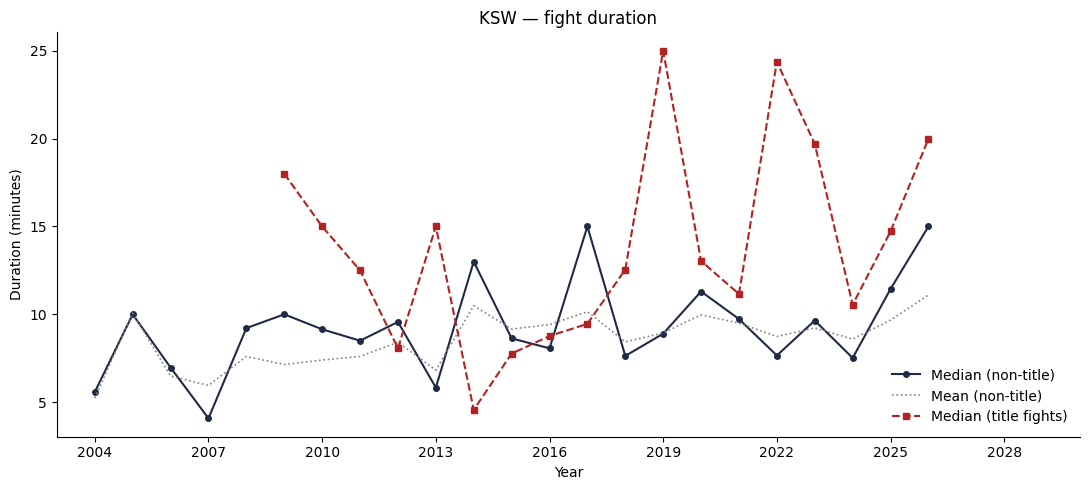

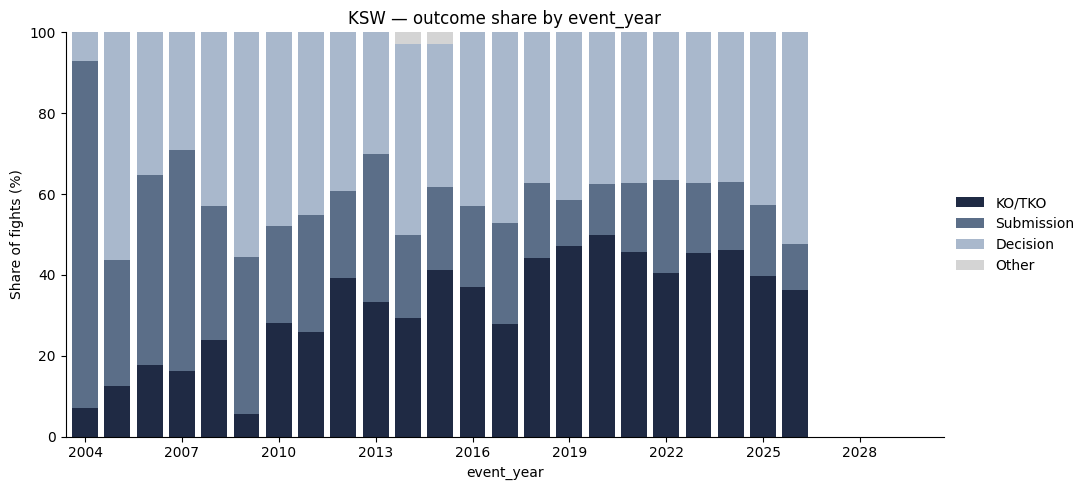

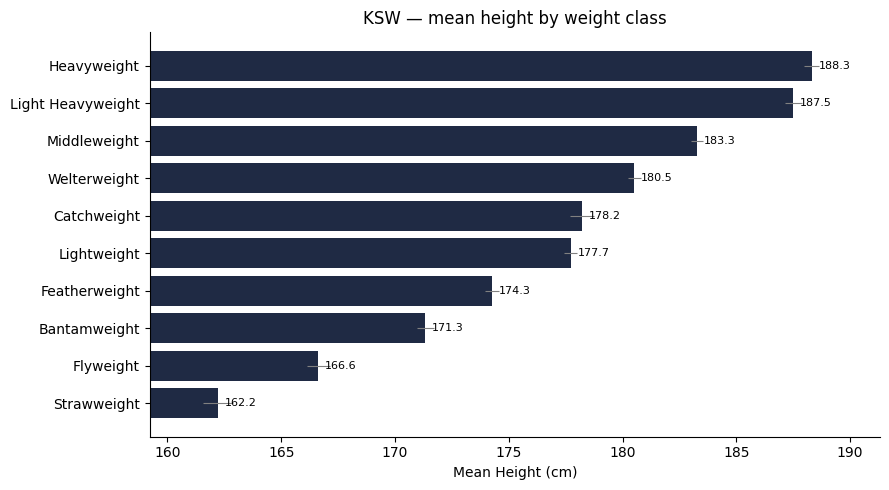

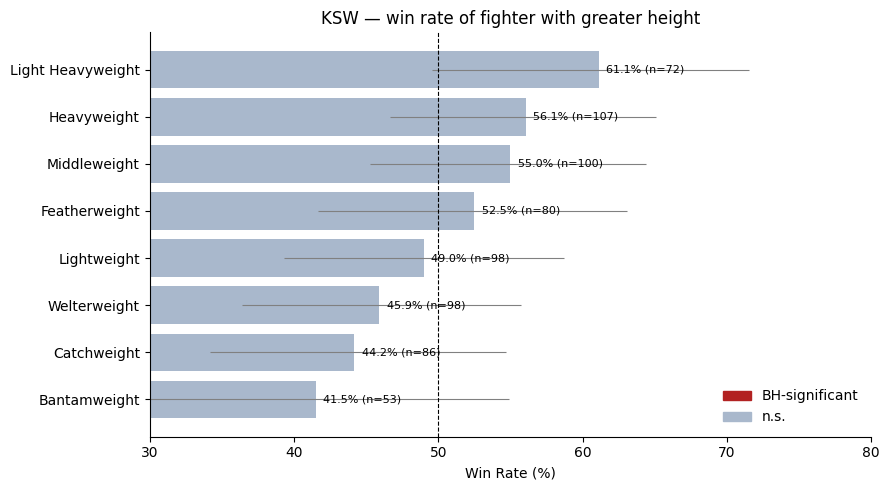

In [1]:
import re
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import MaxNLocator
from scipy import stats
from statsmodels.stats.multitest import multipletests
import statsmodels.api as sm


DATA_DIR = '/kaggle/input/datasets/leandroiber/ksw-mma-dataset'
CSV_PATH = f'{DATA_DIR}/clean_sherdog_ksw.csv'
JSON_PATH = f'{DATA_DIR}/ksw_win_title_data.json'


def temporal_aggregation(df, time_col, value_col, group_col=None,
                         agg_funcs=('median', 'mean'), trend_test=True):
    funcs = list(agg_funcs) + ['count', 'std']
    if group_col is None:
        agg = df.groupby(time_col)[value_col].agg(funcs)
    else:
        agg = df.groupby([time_col, group_col])[value_col].agg(funcs).unstack()

    out = {'aggregation': agg}
    if trend_test:
        clean = df[[time_col, value_col]].dropna()
        if len(clean) > 3:
            rho, p = stats.spearmanr(clean[time_col], clean[value_col])
            out['spearman'] = {'rho': rho, 'p_value': p, 'n': len(clean)}
    return out


def categorical_composition_over_time(df, time_col, category_col,
                                      split_point=None, normalize=True):
    counts = df.groupby([time_col, category_col]).size().unstack(fill_value=0)
    proportions = counts.div(counts.sum(axis=1), axis=0) if normalize else counts

    out = {'proportions': proportions, 'counts': counts}

    if split_point is not None:
        before = df[df[time_col] < split_point][category_col].value_counts()
        after = df[df[time_col] >= split_point][category_col].value_counts()
        contingency = pd.DataFrame({'before': before, 'after': after}).fillna(0)
        chi2, p, dof, _ = stats.chi2_contingency(contingency)
        n = contingency.sum().sum()
        cramers_v = np.sqrt(chi2 / (n * (min(contingency.shape) - 1)))
        out['regime_test'] = {
            'chi2': chi2, 'p_value': p, 'dof': dof,
            'cramers_v': cramers_v, 'n': int(n),
            'contingency': contingency
        }
    return out


def group_descriptive(df, group_col, value_col, min_n=5):
    g = df.dropna(subset=[group_col, value_col]).groupby(group_col)[value_col]
    out = g.agg(['count', 'mean', 'std', 'median',
                 lambda x: x.quantile(0.25),
                 lambda x: x.quantile(0.75)])
    out.columns = ['n', 'mean', 'std', 'median', 'q25', 'q75']
    out['iqr'] = out['q75'] - out['q25']
    out = out[out['n'] >= min_n]
    return out.sort_values('mean', ascending=False)


def paired_advantage_test(df, group_col, attr_a_col, attr_b_col,
                          winner_is_a_col=None,
                          min_n=30, mc_method='fdr_bh', alpha=0.05):
    results = []
    for group, sub in df.groupby(group_col):
        sub = sub.dropna(subset=[attr_a_col, attr_b_col]).copy()
        if winner_is_a_col is not None:
            sub = sub.dropna(subset=[winner_is_a_col])
            a_won = sub[winner_is_a_col].astype(bool)
        else:
            a_won = pd.Series(True, index=sub.index)

        sub = sub[sub[attr_a_col] != sub[attr_b_col]]
        a_won = a_won.loc[sub.index]
        n = len(sub)

        if n < min_n:
            results.append({'group': group, 'n': n, 'underpowered': True})
            continue

        a_greater = sub[attr_a_col] > sub[attr_b_col]
        greater_won = (a_greater & a_won) | (~a_greater & ~a_won)
        wins = int(greater_won.sum())

        ci_low, ci_high = stats.binomtest(wins, n).proportion_ci(method='wilson')
        p_value = stats.binomtest(wins, n, p=0.5, alternative='two-sided').pvalue

        results.append({
            'group': group, 'n': n, 'win_rate': wins / n,
            'ci_low': ci_low, 'ci_high': ci_high,
            'p_value': p_value, 'underpowered': False
        })

    res = pd.DataFrame(results)
    res['p_adjusted'] = np.nan
    res['significant'] = False
    res['underpowered'] = res['underpowered'].astype(bool)

    valid = ~res['underpowered']
    if valid.sum() > 0:
        _, p_adj, _, _ = multipletests(res.loc[valid, 'p_value'],
                                       method=mc_method, alpha=alpha)
        res.loc[valid, 'p_adjusted'] = p_adj
        res.loc[valid, 'significant'] = p_adj < alpha
    return res.sort_values('win_rate', ascending=False, na_position='last')


def continuous_advantage_logit(df, group_col, diff_cols, target_col,
                               covariates=None, min_n=50):
    rows = []
    cols = list(diff_cols) + (covariates or [])
    for group, sub in df.groupby(group_col):
        sub = sub.dropna(subset=cols + [target_col])
        if len(sub) < min_n:
            continue
        X = sm.add_constant(sub[cols])
        y = sub[target_col].astype(int)
        try:
            m = sm.Logit(y, X).fit(disp=0)
            for c in cols:
                rows.append({
                    'group': group, 'predictor': c, 'n': len(sub),
                    'coef': m.params[c],
                    'odds_ratio': np.exp(m.params[c]),
                    'p_value': m.pvalues[c],
                    'or_ci_low': np.exp(m.conf_int().loc[c, 0]),
                    'or_ci_high': np.exp(m.conf_int().loc[c, 1]),
                    'pseudo_r2': m.prsquared
                })
        except Exception as e:
            rows.append({'group': group, 'error': str(e)})
    return pd.DataFrame(rows)


def load_ksw():
    df = pd.read_csv(CSV_PATH)
    df = df[df['event_status'] == 'REALIZADO'].copy()
    df['event_date'] = pd.to_datetime(df['event_date'], utc=True, errors='coerce')
    df['event_year'] = df['event_date'].dt.year

    def time_to_min(row):
        try:
            m, s = map(int, str(row['time']).split(':'))
            r = int(row['round_num'])
            if r < 1:
                return np.nan
            return (r - 1) * 5 + m + s / 60
        except (ValueError, TypeError):
            return np.nan
    df['duration_min'] = df.apply(time_to_min, axis=1)

    def bucket_method(m):
        if pd.isna(m):
            return np.nan
        m = m.lower()
        if 'submission' in m:
            return 'Submission'
        if 'ko' in m or 'tko' in m:
            return 'KO/TKO'
        if 'decision' in m:
            return 'Decision'
        return 'Other'
    df['method_bucket'] = df['method'].apply(bucket_method)

    df['weight_class_clean'] = df['weight_class'].apply(
        lambda x: 'Catchweight' if pd.notna(x) and re.search(r'Catch', str(x), re.I) else x
    )

    df['decisive'] = df['fighter_1_result'] == 'win'

    with open(JSON_PATH) as f:
        title_data = json.load(f)
    title_map = {}
    for k, v in title_data.items():
        key = (v.get('event_date'), v.get('fighter_1'), v.get('fighter_2'))
        title_map[key] = v.get('is_title_fight', False)
    df['_date_str'] = df['event_date'].dt.strftime('%Y-%m-%d')
    df['is_title_fight'] = df.apply(
        lambda r: title_map.get((r['_date_str'], r['fighter_1'], r['fighter_2']), False),
        axis=1
    )
    df = df.drop(columns=['_date_str'])
    return df


def q1_duration_over_time(df, x_max=2030):
    non_title = df[~df['is_title_fight'] & df['decisive']]
    title = df[df['is_title_fight'] & df['decisive']]

    nt_res = temporal_aggregation(non_title, 'event_year', 'duration_min')
    t_res = temporal_aggregation(title, 'event_year', 'duration_min', trend_test=False)

    fig, ax = plt.subplots(figsize=(11, 5))
    nt_agg = nt_res['aggregation']
    ax.plot(nt_agg.index, nt_agg['median'], '-o', color='#1f2a44',
            label='Median (non-title)', markersize=4)
    ax.plot(nt_agg.index, nt_agg['mean'], ':', color='gray',
            label='Mean (non-title)', linewidth=1.2)
    if len(t_res['aggregation']) > 0:
        t_agg = t_res['aggregation']
        ax.plot(t_agg.index, t_agg['median'], '--s', color='#b22222',
                label='Median (title fights)', markersize=4)
    ax.set_xlabel('Year')
    ax.set_ylabel('Duration (minutes)')
    ax.set_title('KSW — fight duration')
    ax.legend(loc='lower right', frameon=False)
    ax.set_xlim(df['event_year'].min() - 1, x_max)
    ax.xaxis.set_major_locator(MaxNLocator(integer=True, nbins=10))
    sns.despine()
    plt.tight_layout()
    return fig, nt_res, t_res


def q2_outcome_share_over_time(df, split_year=2020, x_max=2030):
    decisive = df[df['decisive']].dropna(subset=['method_bucket'])
    res = categorical_composition_over_time(
        decisive, 'event_year', 'method_bucket', split_point=split_year
    )

    order = ['KO/TKO', 'Submission', 'Decision', 'Other']
    props = res['proportions'].reindex(columns=order, fill_value=0) * 100

    fig, ax = plt.subplots(figsize=(11, 5))
    palette = {'KO/TKO': '#1f2a44', 'Submission': '#5b6e88',
               'Decision': '#a9b8cc', 'Other': '#d4d4d4'}
    bottom = np.zeros(len(props))
    for cat in order:
        ax.bar(props.index, props[cat], bottom=bottom, label=cat, color=palette[cat])
        bottom += props[cat].values
    ax.set_xlabel('event_year')
    ax.set_ylabel('Share of fights (%)')
    ax.set_title('KSW — outcome share by event_year')
    ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), frameon=False)
    ax.set_ylim(0, 100)
    ax.set_xlim(props.index.min() - 0.6, x_max + 0.6)
    ax.xaxis.set_major_locator(MaxNLocator(integer=True, nbins=10))
    sns.despine()
    plt.tight_layout()
    return fig, res


def q3_height_by_weight_class(df, min_n=10):
    valid_classes = df['weight_class_clean'].value_counts()
    valid_classes = valid_classes[valid_classes >= min_n].index
    sub = df[df['weight_class_clean'].isin(valid_classes)]

    long = pd.concat([
        sub[['weight_class_clean', 'f1_height_cm']].rename(columns={'f1_height_cm': 'height'}),
        sub[['weight_class_clean', 'f2_height_cm']].rename(columns={'f2_height_cm': 'height'})
    ])
    desc = group_descriptive(long, 'weight_class_clean', 'height', min_n=min_n)

    fig, ax = plt.subplots(figsize=(9, 5))
    desc_sorted = desc.sort_values('mean')
    ax.barh(desc_sorted.index, desc_sorted['mean'], color='#1f2a44',
            xerr=desc_sorted['std'] / np.sqrt(desc_sorted['n']),
            error_kw={'ecolor': 'gray', 'linewidth': 0.8})
    for i, (idx, row) in enumerate(desc_sorted.iterrows()):
        ax.text(row['mean'] + 0.3, i, f"{row['mean']:.1f}",
                va='center', fontsize=8)
    ax.set_xlabel('Mean Height (cm)')
    ax.set_title('KSW — mean height by weight class')
    ax.set_xlim(desc_sorted['mean'].min() - 3, desc_sorted['mean'].max() + 3)
    sns.despine()
    plt.tight_layout()
    return fig, desc


def q4_height_advantage(df, min_n=30):
    sub = df[df['decisive']].dropna(
        subset=['f1_height_cm', 'f2_height_cm', 'weight_class_clean']
    ).copy()
    valid_classes = sub['weight_class_clean'].value_counts()
    sub = sub[sub['weight_class_clean'].isin(valid_classes[valid_classes >= min_n].index)]

    sub['winner_is_f1'] = True
    res = paired_advantage_test(
        sub, group_col='weight_class_clean',
        attr_a_col='f1_height_cm', attr_b_col='f2_height_cm',
        winner_is_a_col='winner_is_f1', min_n=min_n
    )

    fig, ax = plt.subplots(figsize=(9, 5))
    valid = res[~res['underpowered']].copy()
    valid = valid.sort_values('win_rate')
    colors = ['#b22222' if s else '#a9b8cc' for s in valid['significant']]
    ax.barh(valid['group'], valid['win_rate'] * 100, color=colors,
            xerr=[(valid['win_rate'] - valid['ci_low']) * 100,
                  (valid['ci_high'] - valid['win_rate']) * 100],
            error_kw={'ecolor': 'gray', 'linewidth': 0.8})
    ax.axvline(50, ls='--', color='black', linewidth=0.8)
    for i, (_, row) in enumerate(valid.iterrows()):
        ax.text(row['win_rate'] * 100 + 0.5, i,
                f"{row['win_rate']*100:.1f}% (n={row['n']})",
                va='center', fontsize=8)
    ax.set_xlabel('Win Rate (%)')
    ax.set_title('KSW — win rate of fighter with greater height')
    ax.set_xlim(30, 80)
    handles = [plt.Rectangle((0, 0), 1, 1, color='#b22222'),
               plt.Rectangle((0, 0), 1, 1, color='#a9b8cc')]
    ax.legend(handles, ['BH-significant', 'n.s.'], loc='lower right', frameon=False)
    sns.despine()
    plt.tight_layout()
    return fig, res


if __name__ == '__main__':
    df = load_ksw()
    print(f"Lutas REALIZADO: {len(df)} | Período: {df['event_year'].min()}-{df['event_year'].max()}")
    print(f"Decisivas: {df['decisive'].sum()} | Title fights: {df['is_title_fight'].sum()}")

    fig1, q1_nt, q1_t = q1_duration_over_time(df)
    fig1.savefig('q1_ksw_duration.png', dpi=120, bbox_inches='tight')
    print(f"\n[Q1] Spearman (year vs duration, non-title): "
          f"rho={q1_nt['spearman']['rho']:.3f}, "
          f"p={q1_nt['spearman']['p_value']:.4g}, "
          f"n={q1_nt['spearman']['n']}")

    fig2, q2 = q2_outcome_share_over_time(df, split_year=2020)
    fig2.savefig('q2_ksw_outcomes.png', dpi=120, bbox_inches='tight')
    rt = q2['regime_test']
    print(f"\n[Q2] Qui-quadrado pre/post-2020: "
          f"chi2={rt['chi2']:.2f}, p={rt['p_value']:.4g}, "
          f"V de Cramer={rt['cramers_v']:.3f}, n={rt['n']}")

    fig3, q3 = q3_height_by_weight_class(df, min_n=10)
    fig3.savefig('q3_ksw_height.png', dpi=120, bbox_inches='tight')
    print(f"\n[Q3] Classes analisadas: {len(q3)}")
    print(q3[['n', 'mean', 'std', 'median']].round(2))

    fig4, q4 = q4_height_advantage(df, min_n=30)
    fig4.savefig('q4_ksw_height_winrate.png', dpi=120, bbox_inches='tight')
    print(f"\n[Q4] Resultados por classe:")
    cols_show = ['group', 'n', 'win_rate', 'ci_low', 'ci_high', 'p_value', 'p_adjusted', 'significant']
    print(q4[cols_show].round(4).to_string(index=False))

## Q1 > Fight Duration Over Time
The series shows a clear upward drift in fight duration across the 2004-2026 window. The non-title median starts around 5-6 minutes in 2004-2007, rises into the 8-10 minute range from 2008-2013, and reaches 11-15 minutes in 2019-2026. The trend is consistent across the period: late-era fights spend systematically more time in the cage than early-era fights. The mean tracks just above the median throughout, indicating the shift is driven by a real change in the central tendency rather than a few long outliers.

Title fights (red dashed line, n = 128 across 22 years) sit consistently above the non-title series and show their own upward pattern. From 2009 onward, title bout medians routinely exceed 12-15 minutes, with peaks at 25 minutes in 2019 and roughly 24 minutes in 2022. This is structurally distinct from non-title behavior: title fights regularly go the full distance, which pushes the median close to the regulation ceiling. The 5-round championship format (25-minute cap vs 15-minute non-title cap) explains part of the gap but does not fully account for it, since non-title fights can also reach the time limit but rarely do.

## Q2 > Outcome Distribution Over Time
The outcome composition shows a statistically significant change across the pre/post-2020 split. The test returns χ² = 28.75, p = 2.52e-06, with Cramér's V = 0.163. The null hypothesis of no association between period and outcome composition is rejected, and the effect size sits in the small-to-moderate range. This is a real regime shift in matchmaking and finishing dynamics, not a noise pattern.

Year-by-year visual composition tracks the shift clearly. The early period (2004-2008) is grappling-dominated: submissions account for 35-65% of decisive fights, KO/TKO sits below 25%, and decisions are present but secondary. From 2009-2014, the composition rebalances toward a more mixed profile. From 2015 onward, KO/TKO climbs into the 35-50% range, submissions compress to 15-20%, and decisions stabilize around 35-40%.

This pattern is consistent with a promotional evolution from a grappling-heavy regional product into a striking-forward mainstream MMA card. Two non-exclusive structural drivers are consistent with the data: a roster transition from the original BJJ and judo-heavy talent pool into a more striking-oriented modern athlete, and a matchmaking shift toward stylistic balance that produces fewer technical finishes and more time-limit outcomes.

## Q3 > Mean Height by Weight Class
The ordinal progression is clean and well-behaved across all ten classes. Heavyweight (188.3 cm, n = 253) leads, followed by Light Heavyweight (187.5 cm, n = 161), with a smooth monotonic decline through Strawweight (162.2 cm, n = 30). The 0.8 cm gap between Heavyweight and Light Heavyweight is in the expected range for these adjacent divisions, and the within-class standard deviations (3.5 to 4.5 cm in most classes) are tight, indicating consistent roster construction across the weight categories.

The absolute height levels are at the upper end of what is typically observed in regional MMA rosters. This is a demographic effect: the Polish population, and Central and Eastern European populations more broadly, sits among the tallest in the world. Polish adult male mean stature is approximately 180-181 cm, against a global mean closer to 171-173 cm. This baseline difference propagates into every weight class on the roster. The heavier divisions are particularly competitive with international standards, since the local talent pool has a natural supply of fighters in the 185-195 cm range. The middle divisions (Welterweight 180.5, Lightweight 177.7) and lighter classes also sit slightly above the equivalent means seen on rosters drawn from East Asian, Latin American, or globally mixed pools.

The Catchweight bucket (178.2 cm, n = 207) is one of the larger categories in the dataset and has by far the highest within-class standard deviation (7.66 cm vs 3.5 to 4.5 cm elsewhere). Catchweight is used extensively as a matchmaking instrument rather than as an exception, and the bucket aggregates fighters across a wide weight range. The mean lands between Welterweight and Lightweight, which reflects the central tendency of the matched weights but masks an underlying multimodal distribution.
Flyweight (n = 55) and Strawweight (n = 30) sit at the lower end of the sample-size range and should be read with wider implicit confidence intervals than the larger divisions.

## Q4 > Win Rate by Height Advantage
No class reaches statistical significance after correcting for multiple testing. Light Heavyweight comes closest with a raw p = 0.0764 (win rate 61.1%, n = 72), but the adjusted p-value (0.589) is well above the α = 0.05 threshold. The formal conclusion is that the evidence is insufficient to reject the null hypothesis of no height effect, which is not the same as concluding that no effect exists.

The directional pattern across classes is unusually balanced. Four classes sit above the 50% baseline (Light Heavyweight 61.1%, Heavyweight 56.1%, Middleweight 55.0%, Featherweight 52.5%) and four sit below (Lightweight 49.0%, Welterweight 45.9%, Catchweight 44.2%, Bantamweight 41.5%). The heavier classes consistently favor the taller fighter, while the middle-to-lighter classes either show no advantage or reverse the direction. Bantamweight at 41.5% is the most pronounced reversal in the series, with the shorter fighter winning roughly nine points more often than the baseline would predict.

The Catchweight result (44.2%, n = 86) is consistent with the structural caveat that applies to that bucket. When fighters are matched across a wide weight range, the height comparison is confounded by the weight asymmetry of the matched pair, and the conditional-on-weight interpretation of the height advantage signal breaks down.
The split between the heavier and lighter halves of the table is suggestive but does not survive correction for multiple comparisons at the current sample sizes. A pooled cross-data analysis would be required to determine whether the directional pattern holds or regresses toward the baseline.

Strawweight and Flyweight were excluded from the test due to insufficient sample after restricting to fights with both heights recorded (n < 30 in each). Including them would require either relaxing the threshold and accepting very wide confidence intervals, or waiting for additional events to accumulate.